In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

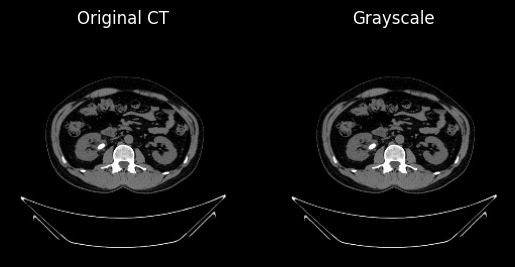

In [ ]:

# STEP 1 — LOAD IMAGE


image_path = r"D:\projects\PythonProject\PythonProject\PythonProject\PythonProject\image_p\dataset\stone\kidney-stone-0101.jpg"    #================ Enter your photo path =================

img = cv2.imread(image_path)

if img is None:
    raise ValueError("Image not found")

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Original
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original CT")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

PREPROCESSING

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

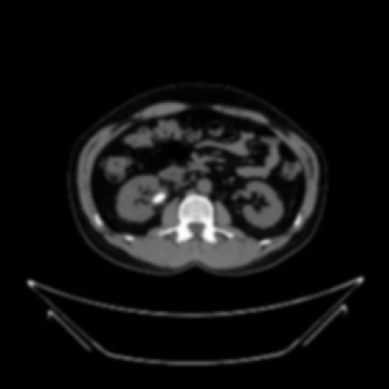

In [ ]:
# STEP 2 — PREPROCESSING


# Gaussian blur for noise reduction
blur = cv2.GaussianBlur(gray, (5,5), 0)

# CLAHE contrast enhancement
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

enhanced = blur


plt.imshow(enhanced, cmap='gray')
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

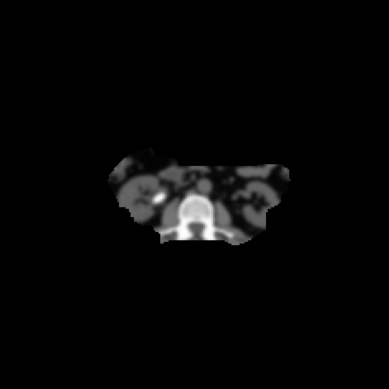

In [ ]:

# AUTOMATIC BODY/IMAGE SHAPE DETECTION
# Removes outer black/background region


# Threshold to separate body from background
_, body_thresh = cv2.threshold(
    enhanced,
    15,
    255,
    cv2.THRESH_BINARY
)

# Find outer contours
contours, _ = cv2.findContours(
    body_thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Create empty mask
body_mask = np.zeros_like(enhanced)

# Get largest contour (main body/image area)
largest_contour = max(contours, key=cv2.contourArea)

# Draw filled contour
cv2.drawContours(
    body_mask,
    [largest_contour],
    -1,
    255,
    thickness=cv2.FILLED
)

# Apply mask
enhanced = cv2.bitwise_and(
    enhanced,
    body_mask
)

# REMOVE 100 PIXELS FROM DETECTED EDGE


remove_pixels = 34

# Create erosion kernel
kernel = np.ones((remove_pixels, remove_pixels), np.uint8)

# Shrink mask inward
inner_mask = cv2.erode(
    body_mask,
    kernel,
    iterations=1
)

# Apply new mask
enhanced = cv2.bitwise_and(
    enhanced,
    inner_mask
)


plt.imshow(enhanced, cmap='gray')
plt.axis("off")


THRESHOLD SEGMENTATION

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

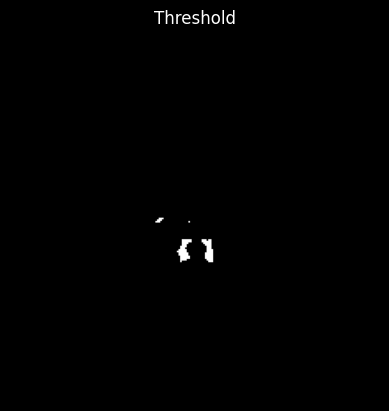

In [ ]:

# STEP 3 — THRESHOLD SEGMENTATION


# Stones are very bright in CT
_, thresh = cv2.threshold(
    enhanced,
    225,
    255,
    cv2.THRESH_BINARY
)
plt.imshow(thresh, cmap='gray')
plt.title("Threshold")
plt.axis("off")

MORPHOLOGICAL CLEANING

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

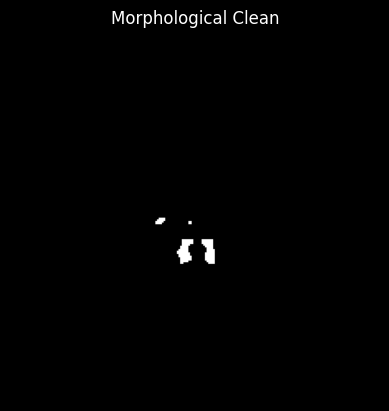

In [ ]:

# STEP 4 — MORPHOLOGICAL CLEANING


kernel = np.ones((1,1), np.uint8)

# Remove tiny noise
clean = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel
)

# Slight dilation to restore shape
kernel = np.ones((2,2), np.uint8)
clean = cv2.dilate(clean, kernel, iterations=1)
plt.imshow(clean, cmap='gray')
plt.title("Morphological Clean")
plt.axis("off")


REMOVE SPINE USING CONNECTED COMPONENTS

In [ ]:

# STEP 5 — REMOVE SPINE USING CONNECTED COMPONENTS


num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(clean)

filtered = np.zeros_like(clean)

height, width = clean.shape

for i in range(1, num_labels):

    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    cx, cy = centroids[i]


    # SPINE CONDITIONS


    is_spine = (
        area > 400 and
        width * 0.35 < cx < width * 0.65 and
        cy > height * 0.45
    )

    # Keep only valid small bright regions
    if not is_spine:

        if 3 < area < 150:
            filtered[labels == i] = 255

In [ ]:

# STEP 6 — REMOVE CENTRAL SPINE REGION


# Extra protection against vertebra detection

cv2.rectangle(
    filtered,
    (int(width * 0.40), int(height * 0.55)),
    (int(width * 0.60), height),
    0,
    -1
)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(224, 224), dtype=uint8)

In [ ]:

# STEP 7 — KIDNEY ROI MASK


roi_mask = np.zeros_like(filtered)

# Left kidney region
cv2.rectangle(
    roi_mask,
    (int(width * 0.10), int(height * 0.30)),
    (int(width * 0.45), int(height * 0.80)),
    255,
    -1
)

# Right kidney region
cv2.rectangle(
    roi_mask,
    (int(width * 0.55), int(height * 0.30)),
    (int(width * 0.90), int(height * 0.80)),
    255,
    -1
)

# Apply ROI mask
kidney_only = cv2.bitwise_and(filtered, roi_mask)

In [ ]:

# STEP 8 — FIND CONTOURS


contours, _ = cv2.findContours(
    kidney_only,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Output image
output = img_rgb.copy()

stone_count = 0

In [ ]:

# STEP 9 — FILTER STONE CANDIDATES


for cnt in contours:

    area = cv2.contourArea(cnt)

    # Ignore too small / too large objects
    if 3 < area < 120:

        perimeter = cv2.arcLength(cnt, True)

        if perimeter == 0:
            continue

        circularity = 4 * np.pi * area / (perimeter ** 2)

        # Stones are compact
        if circularity > 0.40:

            stone_count += 1

            x, y, w, h = cv2.boundingRect(cnt)

            # Draw contour
            cv2.drawContours(
                output,
                [cnt],
                -1,
                (0,255,0),
                2
            )

            # Draw rectangle
            cv2.rectangle(
                output,
                (x,y),
                (x+w,y+h),
                (255,0,0),
                2
            )

            # Label
            cv2.putText(
                output,
                "STONE",
                (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255,255,0),
                1
            )

            print("================================")
            print("STONE DETECTED")
            print("================================")
            print(f"Area        : {area}")
            print(f"Perimeter   : {perimeter:.2f}")
            print(f"Circularity : {circularity:.3f}")
            print()


STONE DETECTED
Area        : 11.0
Perimeter   : 13.66
Circularity : 0.741



DISPLAY RESULTS

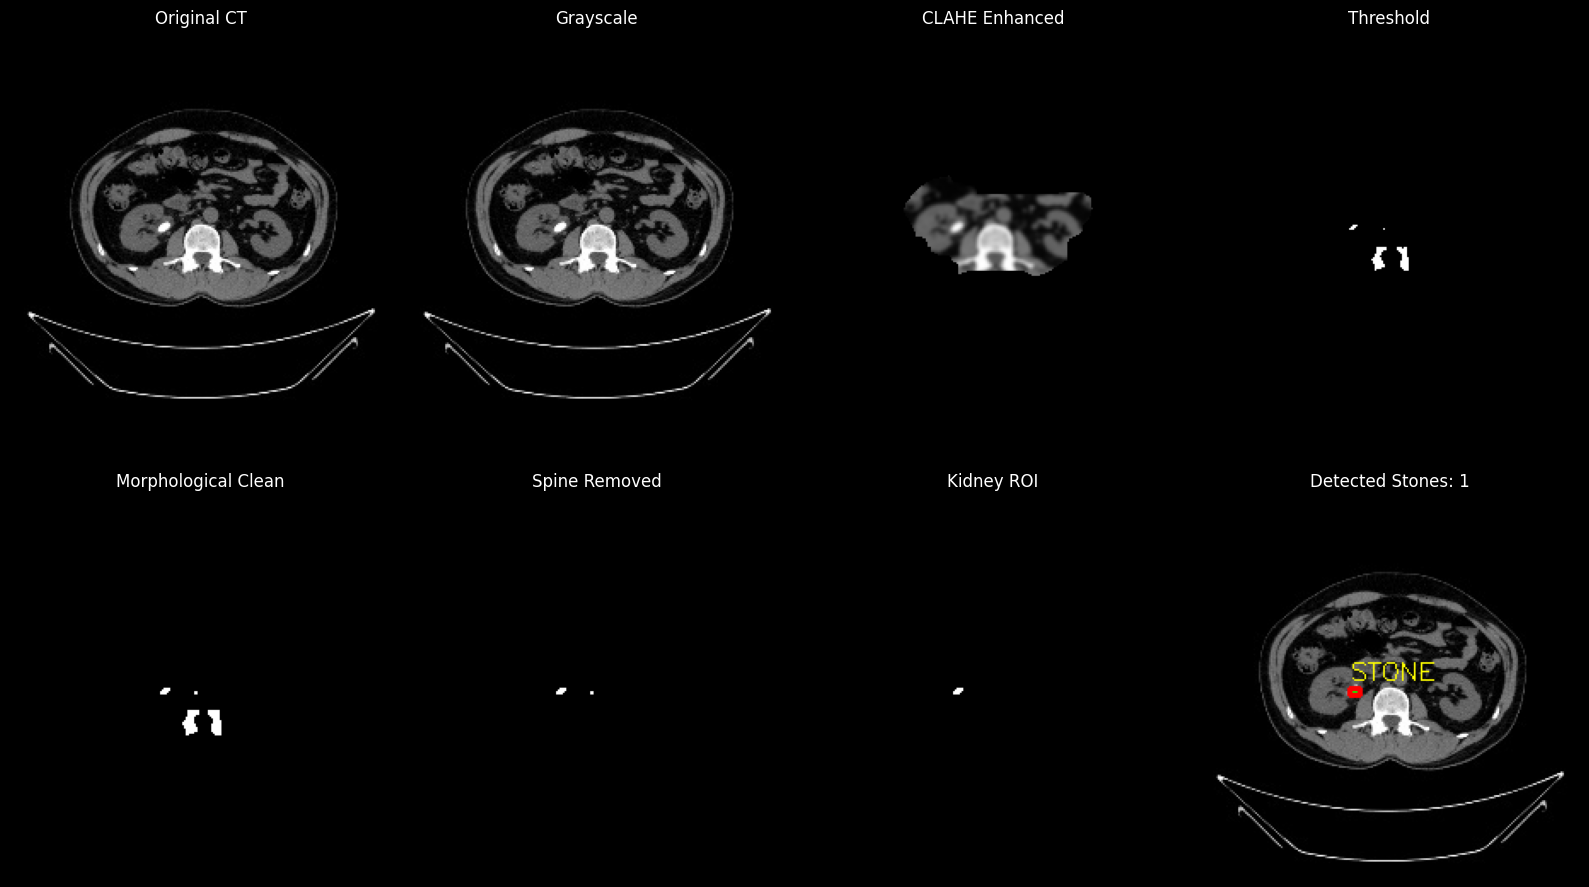

In [ ]:

# STEP 10 — DISPLAY RESULTS


plt.figure(figsize=(16,10))

# Original
plt.subplot(2,4,1)
plt.imshow(img_rgb)
plt.title("Original CT")
plt.axis("off")

# Grayscale
plt.subplot(2,4,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

# Enhanced
plt.subplot(2,4,3)
plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE Enhanced")
plt.axis("off")

# Threshold
plt.subplot(2,4,4)
plt.imshow(thresh, cmap='gray')
plt.title("Threshold")
plt.axis("off")

# Morphological
plt.subplot(2,4,5)
plt.imshow(clean, cmap='gray')
plt.title("Morphological Clean")
plt.axis("off")

# Spine Removed
plt.subplot(2,4,6)
plt.imshow(filtered, cmap='gray')
plt.title("Spine Removed")
plt.axis("off")

# Kidney ROI
plt.subplot(2,4,7)
plt.imshow(kidney_only, cmap='gray')
plt.title("Kidney ROI")
plt.axis("off")

# Final Detection
plt.subplot(2,4,8)
plt.imshow(output)
plt.title(f"Detected Stones: {stone_count}")
plt.axis("off")

plt.tight_layout()
plt.show()



In [ ]:
# ============================================================
# FINAL RESULT
# ============================================================

if stone_count > 0:
    print(f"\nFINAL RESULT: {stone_count} Kidney Stone(s) Detected")
else:
    print("\nFINAL RESULT: No Kidney Stone Detected")


FINAL RESULT: 1 Kidney Stone(s) Detected
